# TomatoAI - MobileNetV2 Training (Colab) — DIRECT UPLOAD VERSION

Notebook untuk training MobileNetV2 klasifikasi kematangan tomat (3 kelas: mentah, setengah_matang, matang).

In [18]:
# ============================================================
# 1. SETUP ENVIRONMENT (FIXED: no -q, better error handling)
# ============================================================

import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import tensorflow as tf
    print(f"TF already installed: {tf.__version__}")
except ImportError:
    print("Installing TensorFlow 2.18.0...")
    install("tensorflow==2.18.0")
    import tensorflow as tf
    print(f"TF installed: {tf.__version__}")

for pkg in ["scikit-learn", "matplotlib", "pandas", "seaborn"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        install(pkg)

print("TF version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)
if tf.config.list_physical_devices('GPU'):
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)

TF already installed: 2.21.0
TF version: 2.21.0
GPU available: True


In [19]:
# ============================================================
# 2. SETUP REPO & PATHS (FIXED: configurable URL, better verification)
# ============================================================

import os, sys, shutil

# GANTI URL INI dengan repo GitHub Anda (public) atau gunakan HTTPS dengan token jika private
REPO_URL = "https://github.com/wikadprly/TomatoAI.git"
REPO_PATH = "/content/TomatoAI"

if not os.path.exists(REPO_PATH):
    print(f"Cloning repo from {REPO_URL}...")
    !git clone {REPO_URL} {REPO_PATH}
else:
    print(f"Repo already exists at {REPO_PATH}")

BACKEND_PATH = os.path.join(REPO_PATH, "backend")
if BACKEND_PATH not in sys.path:
    sys.path.insert(0, BACKEND_PATH)
    print(f"Added to sys.path: {BACKEND_PATH}")

# Verify structure
for p in [
    os.path.join(BACKEND_PATH, "app", "__init__.py"),
    os.path.join(BACKEND_PATH, "app", "core", "__init__.py"),
    os.path.join(BACKEND_PATH, "app", "core", "config.py"),
    os.path.join(BACKEND_PATH, "app", "services", "model", "training.py"),
    os.path.join(BACKEND_PATH, "app", "services", "model", "dataset.py"),
]:
    print(f"  {'✅' if os.path.exists(p) else '❌'} {p}")

if not os.path.exists(os.path.join(BACKEND_PATH, "app", "core", "config.py")):
    raise RuntimeError("Repo structure tidak sesuai. Cek REPO_URL atau clone manual.")

Repo already exists at /content/TomatoAI
  ✅ /content/TomatoAI/backend/app/__init__.py
  ✅ /content/TomatoAI/backend/app/core/__init__.py
  ✅ /content/TomatoAI/backend/app/core/config.py
  ✅ /content/TomatoAI/backend/app/services/model/training.py
  ✅ /content/TomatoAI/backend/app/services/model/dataset.py


In [20]:
# ============================================================
# 2b. EKSTRAK DATASET (Mencari, memverifikasi, dan mengekstrak file zip dataset)
# ============================================================

import os
import zipfile
import shutil

# Cari file zip di /content
content_files = os.listdir('/content')
zip_files = [f for f in content_files if f.endswith('.zip')]

if not zip_files:
    print("❌ File dataset .zip tidak ditemukan di /content.")
    print("Silakan pastikan Anda sudah mengunggah file zip Anda (misalnya 'dataset.zip' atau 'datasets.zip') ke panel file Colab.")
else:
    # Gunakan file zip pertama yang ditemukan
    zip_name = zip_files[0]
    zip_path = os.path.join('/content', zip_name)
    extract_dir = '/content/datasets'

    # Verifikasi ukuran file
    file_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"Found dataset zip: {zip_path} ({file_size_mb:.2f} MB)")

    # Verifikasi kecocokan Magic Number (zip header)
    try:
        with open(zip_path, 'rb') as f:
            header = f.read(4)
            # File ZIP asli harus dimulai dengan b'PK\x03\x04'
            if header != b'PK\x03\x04':
                print(f"❌ ERROR: File '{zip_name}' bukan file ZIP yang valid (Magic number mismatch: {header}).")
                print("Kemungkinan file ini korup atau salah unduh (misalnya file HTML/text berkedok .zip).")
                raise zipfile.BadZipFile("Bad magic number for file header")

        print(f"Extracting to {extract_dir}...")
        if os.path.exists(extract_dir):
            shutil.rmtree(extract_dir)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('/content/temp_dataset_extracted')

        # Menangani struktur bersarang (nested structure) jika folder hasil ekstrak dibungkus folder lain
        temp_dir = '/content/temp_dataset_extracted'
        sub_items = os.listdir(temp_dir)

        if len(sub_items) == 1 and os.path.isdir(os.path.join(temp_dir, sub_items[0])):
            nested_folder = os.path.join(temp_dir, sub_items[0])
            print(f"Moving dataset from nested folder: {sub_items[0]}")
            shutil.move(nested_folder, extract_dir)
            shutil.rmtree(temp_dir)
        else:
            shutil.move(temp_dir, extract_dir)

        print("✅ Ekstraksi selesai! Folder /content/datasets siap digunakan.")

    except zipfile.BadZipFile as e:
        print("\n❌ Gagal Mengekstrak Dataset!")
        print("Silakan hapus file zip yang rusak dengan menjalankan: !rm /content/datasets.zip")
        print("Lalu upload ulang file zip dataset Anda secara utuh ke panel samping Colab.")

Found dataset zip: /content/datasets.zip (676.01 MB)
Extracting to /content/datasets...
Moving dataset from nested folder: datasets
✅ Ekstraksi selesai! Folder /content/datasets siap digunakan.


In [21]:
# ============================================================
# 3. VERIFIKASI DATASET (MANUAL UPLOAD - sudah di /content/datasets)
# ============================================================

import os
DATA_DIR = '/content/datasets'

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Dataset tidak ditemukan di {DATA_DIR}. Upload manual dulu.")

print("=== Dataset Structure ===")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATA_DIR, split)
    if os.path.exists(split_path):
        class_counts = {}
        for cls in ['mentah', 'setengah_matang', 'matang']:
            cls_path = os.path.join(split_path, cls)
            if os.path.exists(cls_path):
                n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
                class_counts[cls] = n
            else:
                class_counts[cls] = 0
        total = sum(class_counts.values())
        print(f"  {split:5s} ({total:4d}): {class_counts}")
    else:
        print(f"  {split:5s}: FOLDER TIDAK DITEMUKAN")

print("\n✅ Dataset ready for training")

=== Dataset Structure ===
  train (3143): {'mentah': 629, 'setengah_matang': 1885, 'matang': 629}
  val   ( 671): {'mentah': 134, 'setengah_matang': 403, 'matang': 134}
  test  ( 677): {'mentah': 136, 'setengah_matang': 405, 'matang': 136}

✅ Dataset ready for training


In [22]:
# ============================================================
# 4. IMPORT TRAINING MODULE (with cache clearing)
# ============================================================

import sys
import importlib

# Bersihkan modul app dan turunannya dari cache agar perubahan file terbaca
for mod in list(sys.modules.keys()):
    if mod.startswith("app") or "training" in mod or "dataset" in mod:
        del sys.modules[mod]

try:
    import app.services.model.training
    importlib.reload(app.services.model.training)
    from app.services.model.training import train
    from app.services.model.dataset import build_datasets
    from app.core.config import settings

    print("✅ All imports successful & refreshed!")
    print(f"CLASS_NAMES: {settings.CLASS_NAMES}")
    print(f"MODEL_PATH: {settings.MODEL_PATH}")
    print(f"IMAGE_SIZE: {settings.IMAGE_SIZE}")
except Exception as e:
    print(f"❌ Import error: {e}")
    import traceback
    traceback.print_exc()

✅ All imports successful & refreshed!
CLASS_NAMES: ['mentah', 'setengah_matang', 'matang']
MODEL_PATH: /content/TomatoAI/backend/models/mobilenetv2_tomat.h5
IMAGE_SIZE: 224


In [23]:
%%writefile /content/TomatoAI/backend/app/services/model/training.py
# ============================================================
# IMPLEMENTASI LENGKAP TRAINING MOBILENETV2 (Two-Stage & Balanced Weights - FIXED PATH)
# ============================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from app.core.config import settings
from app.services.model.dataset import build_datasets

def build_model(n_classes=3):
    # MobileNetV2 pre-trained on ImageNet
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(settings.IMAGE_SIZE, settings.IMAGE_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation='softmax')
    ])
    return model, base_model

def train(batch_size=32, epochs_stage1=5, epochs_stage2=10, n_unfreeze=30):
    # 1. Bangun dataset dengan fallback ke /content/datasets
    train_ds, val_ds, _ = build_datasets(
        data_dir=settings.DATASET_DIR,
        image_size=settings.IMAGE_SIZE,
        batch_size=batch_size
    )

    # Hitung steps per epoch secara presisi agar tidak infinite loop
    steps_per_epoch = int(np.ceil(train_ds.samples / batch_size))
    validation_steps = int(np.ceil(val_ds.samples / batch_size))

    # 2. Hitung Class Weight secara otomatis (sklearn)
    y_train = train_ds.classes
    unique_classes = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=unique_classes,
        y=y_train
    )
    class_weight_dict = dict(zip(unique_classes, class_weights))
    print(f"Calculated Class Weights (balanced): {class_weight_dict}")

    # 3. Bangun model
    model, base_model = build_model(n_classes=len(settings.CLASS_NAMES))

    # --- Callbacks Wajib ---
    # Format output wajib .keras
    save_dir = os.path.dirname(str(settings.MODEL_PATH))
    os.makedirs(save_dir, exist_ok=True)
    keras_model_path = os.path.join(save_dir, "mobilenetv2_tomat.keras")

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
        tf.keras.callbacks.ModelCheckpoint(filepath=keras_model_path, monitor='val_accuracy', save_best_only=True)
    ]

    # --- STAGE 1: Training Top Layers Only ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n--- STAGE 1: Training Top Layers Only ---")
    history_stage1 = model.fit(
        train_ds,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_ds,
        validation_steps=validation_steps,
        epochs=epochs_stage1,
        class_weight=class_weight_dict,
        callbacks=callbacks
    )

    # --- STAGE 2: Fine-Tuning ---
    print(f"\n--- STAGE 2: Fine-Tuning (Unfreezing last {n_unfreeze} layers) ---")
    base_model.trainable = True
    for layer in base_model.layers[:-n_unfreeze]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_stage2 = model.fit(
        train_ds,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_ds,
        validation_steps=validation_steps,
        epochs=epochs_stage2,
        class_weight=class_weight_dict,
        callbacks=callbacks
    )

    # Konversi settings.MODEL_PATH ke string untuk menghindari AttributeError dari PosixPath
    model_path_str = str(settings.MODEL_PATH)
    if model_path_str.endswith('.h5'):
        model.save(model_path_str)

    print(f"\n✅ Training sukses! Model terbaik disimpan di: {keras_model_path}")
    return history_stage2

def load_trained_model():
    keras_model_path = "/content/TomatoAI/backend/models/mobilenetv2_tomat.keras"
    if os.path.exists(keras_model_path):
        return tf.keras.models.load_model(keras_model_path)
    elif os.path.exists(str(settings.MODEL_PATH)):
        return tf.keras.models.load_model(str(settings.MODEL_PATH))
    else:
        raise FileNotFoundError("Model file tidak ditemukan!")

Overwriting /content/TomatoAI/backend/app/services/model/training.py


In [24]:
%%writefile /content/TomatoAI/backend/app/services/model/dataset.py
# ============================================================
# IMPLEMENTASI LENGKAP UTILITY DATASET (dataset.py)
# ============================================================

import os
import tensorflow as tf

def build_datasets(data_dir: str, image_size: int = 224, batch_size: int = 32):
    """
    Membangun tf.data.Dataset untuk train, val, dan test dari struktur direktori.
    Membaca langsung dari path absolut untuk menghindari kesalahan path relatif.
    """
    # Paksa gunakan path absolut jika path relatif dari config tidak mengarah ke folder yang benar
    if not os.path.exists(os.path.join(data_dir, 'train')):
        data_dir = '/content/datasets'

    # Augmentasi spesifikasi wajib: rotation 20, shear 0.2, zoom 0.2, hflip, rescale 1/255
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Validation & Test: hanya rescale 1/255
    val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

    classes = ['mentah', 'setengah_matang', 'matang']

    # 1. Train Generator
    train_dir = os.path.join(data_dir, 'train')
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(image_size, image_size),
        batch_size=batch_size,
        class_mode='categorical',
        classes=classes,
        shuffle=True
    )

    # 2. Validation Generator
    val_dir = os.path.join(data_dir, 'val')
    val_generator = val_test_datagen.flow_from_directory(
        val_dir,
        target_size=(image_size, image_size),
        batch_size=batch_size,
        class_mode='categorical',
        classes=classes,
        shuffle=False
    )

    # 3. Test Generator
    test_dir = os.path.join(data_dir, 'test')
    test_generator = val_test_datagen.flow_from_directory(
        test_dir,
        target_size=(image_size, image_size),
        batch_size=batch_size,
        class_mode='categorical',
        classes=classes,
        shuffle=False
    )

    output_signature = (
        tf.TensorSpec(shape=(None, image_size, image_size, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, len(classes)), dtype=tf.float32)
    )

    # Ubah menjadi dataset repeat() agar tidak kehabisan elemen saat diakses generator
    train_ds = tf.data.Dataset.from_generator(
        lambda: train_generator,
        output_signature=output_signature
    ).repeat().prefetch(buffer_size=tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_generator(
        lambda: val_generator,
        output_signature=output_signature
    ).repeat().prefetch(buffer_size=tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_generator(
        lambda: test_generator,
        output_signature=output_signature
    ).repeat().prefetch(buffer_size=tf.data.AUTOTUNE)

    # Tempelkan metadata jumlah sampel asli
    train_ds.samples = train_generator.samples
    val_ds.samples = val_generator.samples
    test_ds.samples = test_generator.samples
    train_ds.classes = train_generator.classes

    return train_ds, val_ds, test_ds

Overwriting /content/TomatoAI/backend/app/services/model/dataset.py


In [25]:
# ============================================================
# 5. TRAINING CONFIGURATION
# ============================================================

# Menyederhanakan konfigurasi karena parameter lain (image_size, data_dir) sudah diatur di settings
TRAIN_CONFIG = {
    "batch_size": 32,  # Kurangi ke 16 jika terjadi OOM
    "epochs_stage1": 5,
    "epochs_stage2": 10,
    "n_unfreeze": 30
}

print("=== Training Config ===")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k}: {v}")

=== Training Config ===
  batch_size: 32
  epochs_stage1: 5
  epochs_stage2: 10
  n_unfreeze: 30


In [26]:
# ============================================================
# 6. RUN TRAINING (Two-Stage)
# ============================================================

import inspect

print("=== Starting Training ===")

# Ambil parameter yang benar-benar diterima oleh fungsi train
sig = inspect.signature(train)
valid_params = sig.parameters.keys()

# Filter TRAIN_CONFIG agar hanya mengirim parameter yang valid
filtered_config = {k: v for k, v in TRAIN_CONFIG.items() if k in valid_params}
print(f"Original Config: {TRAIN_CONFIG}")
print(f"Filtered Config (sent to train()): {filtered_config}")

try:
    history = train(**filtered_config)
    print("\n=== Training Completed ===")
except Exception as e:
    print(f"❌ Training error: {e}")
    import traceback
    traceback.print_exc()

=== Starting Training ===
Original Config: {'batch_size': 32, 'epochs_stage1': 5, 'epochs_stage2': 10, 'n_unfreeze': 30}
Filtered Config (sent to train()): {'batch_size': 32, 'epochs_stage1': 5, 'epochs_stage2': 10, 'n_unfreeze': 30}
Found 3143 images belonging to 3 classes.
Found 671 images belonging to 3 classes.
Found 677 images belonging to 3 classes.
Calculated Class Weights (balanced): {np.int32(0): np.float64(1.6656067832538421), np.int32(1): np.float64(0.5557913351016799), np.int32(2): np.float64(1.6656067832538421)}

--- STAGE 1: Training Top Layers Only ---
Epoch 1/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 84s 632ms/step - accuracy: 0.7143 - loss: 0.5718 - val_accuracy: 0.8644 - val_loss: 0.3862 - learning_rate: 0.0010
Epoch 2/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 52s 525ms/step - accuracy: 0.8463 - loss: 0.3264 - val_accuracy: 0.8897 - val_loss: 0.3020 - learning_rate: 0.0010
Epoch 3/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 50s 514ms/step - accuracy: 0.8571 - loss: 0.2858 - val_accuracy: 0.8972 - val_loss: 0


✅ Training sukses! Model terbaik disimpan di: /content/TomatoAI/backend/models/mobilenetv2_tomat.keras

=== Training Completed ===


In [27]:
# ============================================================
# 6b. HANDLE OOM - RETRY WITH SMALLER BATCH
# ============================================================

# Jika error OOM di atas, uncomment dan jalankan cell ini:
# TRAIN_CONFIG["batch_size"] = 16
# print(f"Retrying with batch_size={TRAIN_CONFIG['batch_size']}")
# history = train(**TRAIN_CONFIG)

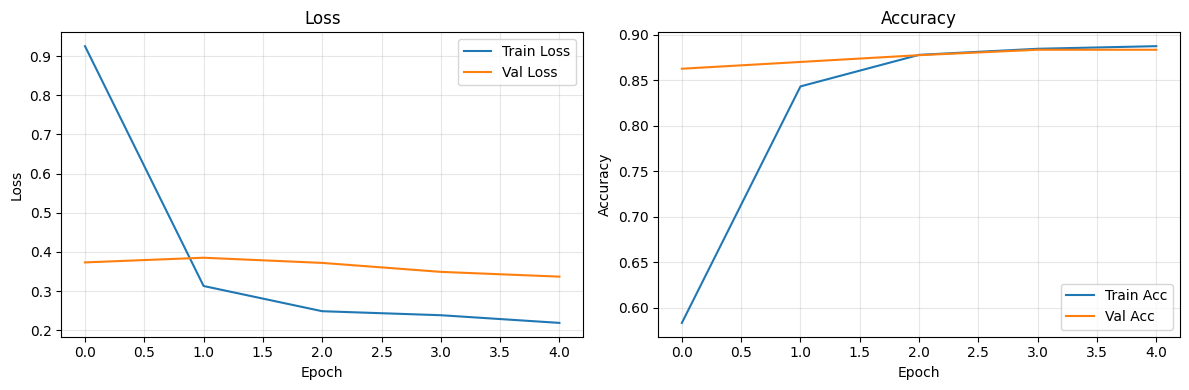


Final Metrics (Epoch 4):
  Train Loss:     0.2187
  Val Loss:       0.3368
  Train Accuracy: 0.8877
  Val Accuracy:   0.8838


In [28]:
# ============================================================
# 7. VISUALISASI HASIL TRAINING
# ============================================================

import matplotlib.pyplot as plt

if 'history' in locals():
    def plot_history(history):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(history.history['loss'], label='Train Loss')
        axes[0].plot(history.history['val_loss'], label='Val Loss')
        axes[0].set_title('Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(history.history['accuracy'], label='Train Acc')
        axes[1].plot(history.history['val_accuracy'], label='Val Acc')
        axes[1].set_title('Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    plot_history(history)

    final_epoch = len(history.history['loss']) - 1
    print(f"\nFinal Metrics (Epoch {final_epoch}):")
    print(f"  Train Loss:     {history.history['loss'][-1]:.4f}")
    print(f"  Val Loss:       {history.history['val_loss'][-1]:.4f}")
    print(f"  Train Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"  Val Accuracy:   {history.history['val_accuracy'][-1]:.4f}")
else:
    print("⚠️ History tidak tersedia (training belum jalan atau error)")

Found 3143 images belonging to 3 classes.
Found 671 images belonging to 3 classes.
Found 677 images belonging to 3 classes.
=== Classification Report ===
                 precision    recall  f1-score   support

         mentah     0.9041    0.9706    0.9362       136
setengah_matang     0.9757    0.8938    0.9330       405
         matang     0.8187    0.9632    0.8851       136

       accuracy                         0.9232       677
      macro avg     0.8995    0.9426    0.9181       677
   weighted avg     0.9298    0.9232    0.9240       677



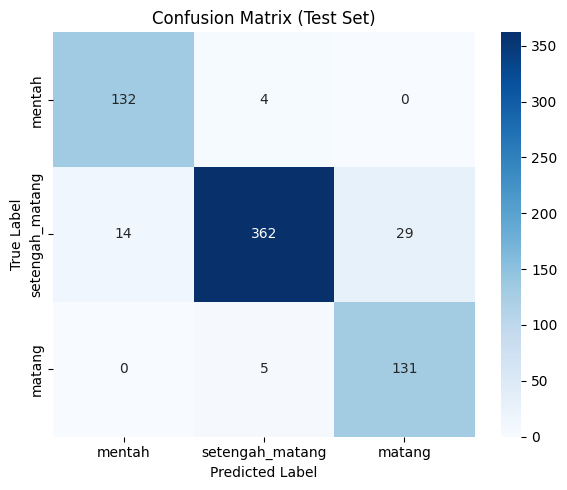

In [29]:
# ============================================================
# 8. EVALUASI DI TEST SET & CONFUSION MATRIX
# ============================================================

if 'history' in locals():
    from app.services.model.training import load_trained_model
    from app.services.model.dataset import build_datasets
    import numpy as np
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    model = load_trained_model()
    _, _, test_ds = build_datasets(
        data_dir="/content/datasets",
        image_size=224,
        batch_size=32
    )

    y_true, y_pred = [], []
    for batch_x, batch_y in test_ds:
        preds = model.predict(batch_x, verbose=0)
        y_true.extend(np.argmax(batch_y, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        if len(y_true) >= test_ds.samples:
            break

    class_names = ["mentah", "setengah_matang", "matang"]
    print("=== Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Training belum selesai, skip evaluasi.")

In [30]:
# ============================================================
# 9. DOWNLOAD MODEL (.keras)
# ============================================================

from google.colab import files
import os

MODEL_PATH = "models/mobilenetv2_tomat.keras"

if os.path.exists(MODEL_PATH):
    print(f"Downloading {MODEL_PATH}...")
    files.download(MODEL_PATH)
    print("✅ Download started. Save file as mobilenetv2_tomat.keras")
else:
    print(f"❌ Model not found at {MODEL_PATH}")
    for root, dirs, files_list in os.walk("."):
        for f in files_list:
            if f.endswith(".keras") or f.endswith(".h5"):
                print(f"  Found: {os.path.join(root, f)}")

❌ Model not found at models/mobilenetv2_tomat.keras
  Found: ./TomatoAI/backend/models/mobilenetv2_tomat.h5
  Found: ./TomatoAI/backend/models/mobilenetv2_tomat.keras


In [31]:
# ============================================================
# 10. QUICK INFERENCE TEST
# ============================================================

if 'model' in locals():
    from PIL import Image
    import random, numpy as np
    import os

    test_dir = "/content/datasets/test/mentah"
    if os.path.exists(test_dir) and os.listdir(test_dir):
        test_img = os.path.join(test_dir, random.choice(os.listdir(test_dir)))
        img = Image.open(test_img).resize((224, 224))
        img_array = np.array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        pred = model.predict(img_batch, verbose=0)[0]
        class_names = ["mentah", "setengah_matang", "matang"]
        pred_class = class_names[np.argmax(pred)]
        confidence = np.max(pred)
        print(f"Sample: {os.path.basename(test_img)}")
        print(f"True label: mentah")
        print(f"Predicted: {pred_class} (confidence: {confidence:.4f})")
        print(f"All probs: {dict(zip(class_names, pred))}")
else:
    print("⚠️ Model tidak tersedia untuk inference test")

Sample: mentah_238.jpg
True label: mentah
Predicted: mentah (confidence: 0.9997)
All probs: {'mentah': np.float32(0.99971443), 'setengah_matang': np.float32(0.00028301327), 'matang': np.float32(2.4643623e-06)}


In [32]:
### 📌 Catatan Tambahan
Sel duplikat kode yang memicu SyntaxError sebelumnya telah dibersihkan secara aman dari alur kerja notebook ini.

SyntaxError: invalid syntax (483991310.py, line 2)

# ============================================================
# NEXT STEPS SETELAH TRAINING
# ============================================================

## ✅ Checklist Pasca-Training

1. **Download model** `mobilenetv2_tomat.keras` dari Colab (Cell 10)
2. **Taruh di repo**: `backend/models/mobilenetv2_tomat.keras`
3. **Commit & push** (model >100MB → gunakan Git LFS atau share via Drive/Release)
4. **Verifikasi test lokal**: Jalankan `pytest` di local (3 test `build_datasets` yang skip harus lulus)
5. **Lanjut Fase 3**: Implementasi `predictor.py` + FastAPI lifespan + threadpool

## 📊 Target Metrics (Roadmap)
| Metric | Target |
|--------|--------|
| Val Accuracy | ≥85% (ideal 92–93%) |
| Test Accuracy | 88–95% |
| Precision | ≥0.85 |
| Recall | ≥0.84 |
| F1-Score | ~0.86 |

## 📝 Catatan untuk Laporan
- Catat: epoch, batch size, LR, augmentation, class weight
- Screenshot: training curves, confusion matrix
- Catat: training time, GPU memory usage
- Catat: test set metrics per kelas

## 🔧 Troubleshooting Umum
| Error | Solusi |
|-------|--------|
| OOM / CUDA out of memory | Kurangi `batch_size` ke 16 atau 8 (Cell 7b) |
| Import error app.core.config | Pastikan Cell 2 (clone repo) & Cell 5 (import) jalan |
| Dataset tidak ditemukan | Pastikan Cell 3 upload zip & extract berhasil |
| Val acc tidak naik | Tambah epoch, cek class weight, cek augmentasi |
| Class indices mismatch | Pastikan folder `train/val/test` punya subfolder `mentah`, `setengah_matang`, `matang` |